# Setup & Config

In [78]:
# 1. Imports & basic setup

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Make plots show inside the notebook
%matplotlib inline

print(os.getcwd())

plt.style.use("seaborn-v0_8")

DATA_PATH = "../datasets/processed/final_combined.csv"


/mnt/partition1/machine_learning/phising_email_detection/notebooks


# Summary for `final_combined.csv`

In [79]:
total_rows = 0
spam_rows = 0
ham_rows = 0
sources = {}

chunksize = 100000  # 100k rows per chunk

print("Reading final_combined.csv ...")

for chunk in pd.read_csv(DATA_PATH, chunksize=chunksize, dtype=str, low_memory=True):

    # label column must be int
    chunk['label'] = chunk['label'].astype(int)

    total_rows += len(chunk)
    spam_rows += (chunk['label'] == 1).sum()
    ham_rows  += (chunk['label'] == 0).sum()

    if 'source' in chunk.columns:
        for s, count in chunk['source'].value_counts().items():
            sources[s] = sources.get(s, 0) + count

print("\n===== FINAL COMBINED CSV SUMMARY =====")
print(f"Total rows        : {total_rows:,}")
print(f"Spam rows         : {spam_rows:,}")
print(f"Ham rows          : {ham_rows:,}")
print(f"Spam percentage   : {spam_rows / total_rows * 100:.2f}%")

print("\nSamples per dataset source:")
for s, c in sorted(sources.items(), key=lambda x: -x[1]):
    print(f"  {s}: {c:,}")

print("\n=== LATEX TABLE ROW ===")
print(f"CSV+EML Combined & {total_rows:,} & {spam_rows / total_rows * 100:.2f}\\% & Body, Attachments, Headers, URLs \\\\")


Reading final_combined.csv ...

===== FINAL COMBINED CSV SUMMARY =====
Total rows        : 181,289
Spam rows         : 90,958
Ham rows          : 90,331
Spam percentage   : 50.17%

Samples per dataset source:
  TREC_07: 53,624
  enron: 47,225
  epvme_phish: 45,403
  TREC_06: 16,331
  SpamAssasin: 5,772
  phising_pot: 5,727
  spamassassin: 3,732
  Nigerian_Fraud: 3,317
  wooyun_xss: 158

=== LATEX TABLE ROW ===
CSV+EML Combined & 181,289 & 50.17\% & Body, Attachments, Headers, URLs \\


# Summary for `final_urls.csv`

In [80]:
FILE = "../datasets/url_feeds/processed/final_urls.csv"

total_urls = 0
malicious_urls = 0
benign_urls = 0

chunksize = 200000  # 200k per chunk

print("Reading final_urls.csv ...")

for chunk in pd.read_csv(FILE, chunksize=chunksize, dtype=str, low_memory=True):

    chunk['label'] = chunk['label'].astype(int)

    total_urls += len(chunk)
    malicious_urls += (chunk['label'] == 1).sum()
    benign_urls += (chunk['label'] == 0).sum()

print("\n===== FINAL URL DATASET SUMMARY =====")
print(f"Total URLs           : {total_urls:,}")
print(f"Malicious URLs       : {malicious_urls:,}")
print(f"Benign URLs          : {benign_urls:,}")
print(f"Malicious percentage : {malicious_urls / total_urls * 100:.2f}%")

print("\n=== LATEX TABLE ROW ===")
print(f"URL Datasets & {total_urls:,} & {malicious_urls / total_urls * 100:.2f}\\% & URL Strings \\\\")

Reading final_urls.csv ...

===== FINAL URL DATASET SUMMARY =====
Total URLs           : 11,026,377
Malicious URLs       : 5,503,860
Benign URLs          : 5,522,517
Malicious percentage : 49.92%

=== LATEX TABLE ROW ===
URL Datasets & 11,026,377 & 49.92\% & URL Strings \\


# Load a SAMPLE first (safe for RAM)

In [81]:
# 2. Load a SAMPLE of the dataset (e.g., 20k rows) for fast EDA

# How many rows to sample for quick analysis
SAMPLE_SIZE = 20000  

# Get total number of rows quickly (without loading whole CSV into RAM)
total_rows = sum(1 for _ in open(DATA_PATH, "r", encoding="utf-8")) - 1  # minus header
print(f"Total rows in file (approx): {total_rows}")

# Choose random row indices to keep
np.random.seed(42)
skip_rows = sorted(
    set(np.random.choice(np.arange(1, total_rows + 1), size=max(total_rows - SAMPLE_SIZE, 0), replace=False))
)

print(f"Skipping {len(skip_rows)} rows, loading ~{SAMPLE_SIZE} rows")

df = pd.read_csv(DATA_PATH)
print("Shape of sample df:", df.shape)
df.head()

Total rows in file (approx): 11371151
Skipping 11351151 rows, loading ~20000 rows
Shape of sample df: (181289, 20)


/tmp/ipykernel_30869/1831832428.py:18: DtypeWarning: Columns (3,4,5,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATA_PATH)


,id,subject,body_text,attachment_text,headers_raw,canonical_raw,from_email,to_email,reply_to_email,date,urls,header_from_reply_mismatch,header_domain_mismatch,header_suspicious_tld,header_received_count,header_to_anomaly,header_x_mailer_anomaly,header_date_malformed,label,source
0,54f0602f-1802-4a2c-8b91-b0d5b00e6ab8,URGENT BUSINESS ASSISTANCE AND PARTNERSHIP,FROM:MR. JAMES NGOLA.\nCONFIDENTIAL TEL: 233-2...,NaN,NaN,NaN,james_ngola2002@maktoob.com,webmaster@aclweb.org,NaN,"Thu, 31 Oct 2002 02:38:20 +0000",NaN,0,0,0,0,0,0,0,1,Nigerian_Fraud
1,e17d1ecb-b809-48a7-a169-3089576cc39a,URGENT ASSISTANCE /RELATIONSHIP (P),"Dear Friend,\n\nI am Mr. Ben Suleman a custom ...",NaN,NaN,NaN,bensul2004nng@spinfinder.com,R@M,NaN,"Thu, 31 Oct 2002 05:10:00 -0000",NaN,0,0,0,0,0,0,0,1,Nigerian_Fraud
2,211e9747-e2f0-4b76-9139-4dc16c012eaf,GOOD DAY TO YOU,FROM HIS ROYAL MAJESTY (HRM) CROWN RULER OF EL...,NaN,NaN,NaN,obong_715@epatra.com,webmaster@aclweb.org,NaN,"Thu, 31 Oct 2002 22:17:55 +0100",NaN,0,0,0,0,0,0,0,1,Nigerian_Fraud
3,3e97c16d-6078-4722-9c9d-7c4f29511a8d,GOOD DAY TO YOU,FROM HIS ROYAL MAJESTY (HRM) CROWN RULER OF EL...,NaN,NaN,NaN,obong_715@epatra.com,webmaster@aclweb.org,NaN,"Thu, 31 Oct 2002 22:44:20 -0000",NaN,0,0,0,0,0,0,0,1,Nigerian_Fraud
4,8db7a7d0-4d74-4575-a19d-d83c820c70cd,I Need Your Assistance.,"Dear sir, \n \nIt is with a heart full of hope...",NaN,NaN,NaN,m_abacha03@www.com,R@M,NaN,"Fri, 01 Nov 2002 01:45:04 +0100",NaN,0,0,0,0,0,0,0,1,Nigerian_Fraud


# Quick schema & basic stats

In [82]:
print("Columns:\n", df.columns.tolist())

print("\nDataFrame info:")
print(df.info())

print("\nLabel value counts:")
print(df["label"].value_counts(dropna=False))

print("\nSources:")
print(df["source"].value_counts())

Columns:
 ['id', 'subject', 'body_text', 'attachment_text', 'headers_raw', 'canonical_raw', 'from_email', 'to_email', 'reply_to_email', 'date', 'urls', 'header_from_reply_mismatch', 'header_domain_mismatch', 'header_suspicious_tld', 'header_received_count', 'header_to_anomaly', 'header_x_mailer_anomaly', 'header_date_malformed', 'label', 'source']

DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181289 entries, 0 to 181288
Data columns (total 20 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   id                          181289 non-null  object
 1   subject                     180441 non-null  object
 2   body_text                   176831 non-null  object
 3   attachment_text             840 non-null     object
 4   headers_raw                 102245 non-null  object
 5   canonical_raw               99119 non-null   object
 6   from_email                  175892 non-null  object
 7   to_e

# Add a few helper features (lengths, url counts)

In [83]:
# 4. Create helper features for analysis (doesn't modify your original CSV on disk)

df["subject"] = df["subject"].astype(str)
df["body_text"] = df["body_text"].astype(str)
df["urls"] = df["urls"].astype(str)

df["subject_len"] = df["subject"].str.len()
df["body_len"] = df["body_text"].str.len()
df["url_count"] = df["urls"].str.split().apply(len)  # number of URLs (space-separated)

df[["subject_len", "body_len", "url_count"]].describe()


,subject_len,body_len,url_count
count,181289.000000,1.812890e+05,181289.000000
mean,33.307994,2.040330e+03,1.678502
std,28.383516,7.267643e+03,8.268282
min,1.000000,1.000000e+00,1.000000
25%,18.000000,3.770000e+02,1.000000
50%,28.000000,8.950000e+02,1.000000
75%,43.000000,1.974000e+03,1.000000
max,3646.000000,1.352789e+06,3131.000000


# Label distribution (ham vs phishing)

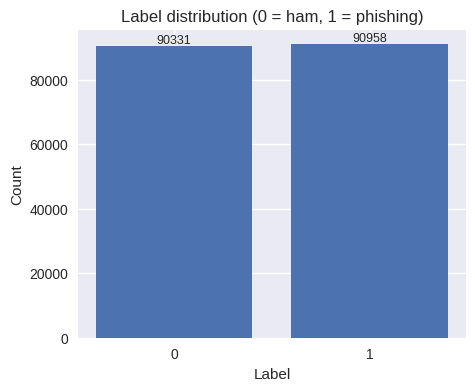

Label percentages (%):
label
0    49.83
1    50.17
Name: count, dtype: float64


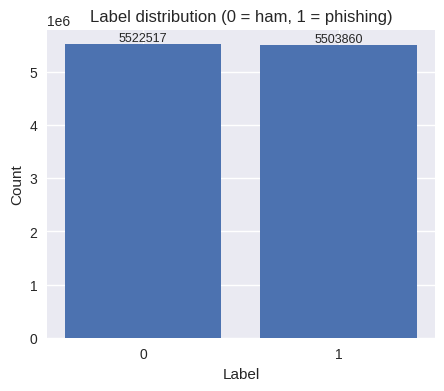

Label percentages (%):
label
0    50.08
1    49.92
Name: count, dtype: float64


In [84]:
# 5. Visualize label distribution

label_counts = df["label"].value_counts().sort_index()
plt.figure(figsize=(5,4))
plt.bar(label_counts.index.astype(str), label_counts.values)
plt.title("Label distribution (0 = ham, 1 = phishing)")
plt.xlabel("Label")
plt.ylabel("Count")
for i, v in enumerate(label_counts.values):
    plt.text(i, v, str(v), ha="center", va="bottom", fontsize=9)
plt.show()

# Also print percentages
print("Label percentages (%):")
print((label_counts / label_counts.sum() * 100).round(2))

df2 = pd.read_csv(FILE)
label_counts = df2["label"].value_counts().sort_index()
plt.figure(figsize=(5,4))
plt.bar(label_counts.index.astype(str), label_counts.values)
plt.title("Label distribution (0 = ham, 1 = phishing)")
plt.xlabel("Label")
plt.ylabel("Count")
for i, v in enumerate(label_counts.values):
    plt.text(i, v, str(v), ha="center", va="bottom", fontsize=9)
plt.show()

# Also print percentages
print("Label percentages (%):")
print((label_counts / label_counts.sum() * 100).round(2))


# Source-wise row counts

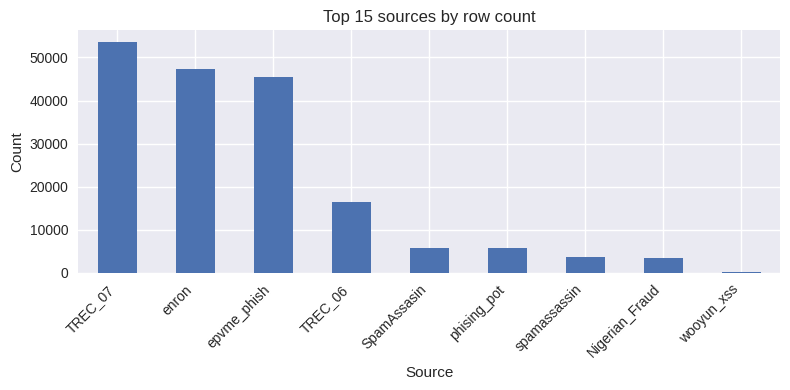

source
TREC_07           53624
enron             47225
epvme_phish       45403
TREC_06           16331
SpamAssasin        5772
phising_pot        5727
spamassassin       3732
Nigerian_Fraud     3317
wooyun_xss          158
Name: count, dtype: int64

In [85]:
# 6. Top sources by row count

source_counts = df["source"].value_counts()
plt.figure(figsize=(8,4))
source_counts.head(15).plot(kind="bar")
plt.title("Top 15 sources by row count")
plt.xlabel("Source")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

source_counts.head(15)


# Text length distribution

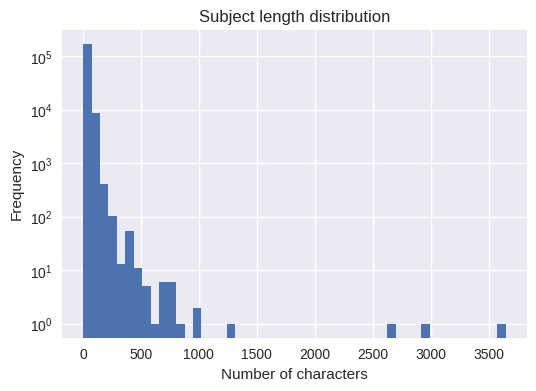

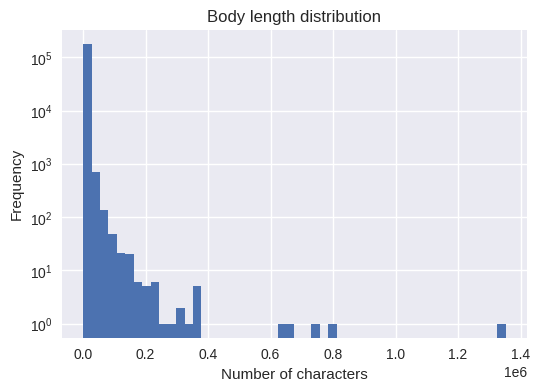

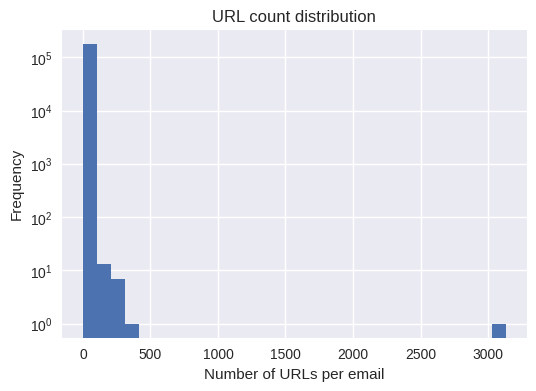

In [86]:
# 7. Subject / body length distributions (log-scale to see tail better)

plt.figure(figsize=(6,4))
plt.hist(df["subject_len"], bins=50)
plt.title("Subject length distribution")
plt.xlabel("Number of characters")
plt.ylabel("Frequency")
plt.yscale("log")
plt.show()

plt.figure(figsize=(6,4))
plt.hist(df["body_len"], bins=50)
plt.title("Body length distribution")
plt.xlabel("Number of characters")
plt.ylabel("Frequency")
plt.yscale("log")
plt.show()

plt.figure(figsize=(6,4))
plt.hist(df["url_count"], bins=30)
plt.title("URL count distribution")
plt.xlabel("Number of URLs per email")
plt.ylabel("Frequency")
plt.yscale("log")
plt.show()

# Identify the anomaly-feature columns

In [87]:
# 8. Identify header anomaly feature columns

header_cols = [c for c in df.columns if c.startswith("header_")]
header_cols

['header_from_reply_mismatch',
 'header_domain_mismatch',
 'header_suspicious_tld',
 'header_received_count',
 'header_to_anomaly',
 'header_x_mailer_anomaly',
 'header_date_malformed']

# Visualize anomaly feature prevalence

Binary anomaly features: ['header_from_reply_mismatch', 'header_domain_mismatch', 'header_suspicious_tld', 'header_to_anomaly', 'header_x_mailer_anomaly', 'header_date_malformed']
Numeric anomaly features: ['header_received_count']


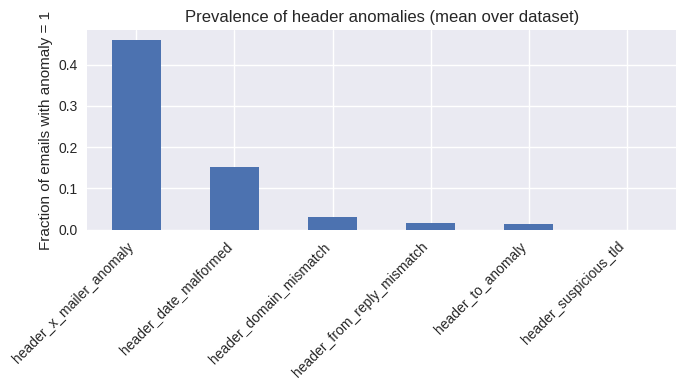

In [88]:
# 9. Visualize prevalence of header anomaly features

# Separate binary anomaly features (0/1) from numeric ones
binary_anoms = []
numeric_anoms = []

for c in header_cols:
    unique_vals = df[c].dropna().unique()
    if set(unique_vals).issubset({0, 1}):
        binary_anoms.append(c)
    else:
        numeric_anoms.append(c)

print("Binary anomaly features:", binary_anoms)
print("Numeric anomaly features:", numeric_anoms)

# Prevalence of binary anomalies
if binary_anoms:
    prevalence = df[binary_anoms].mean().sort_values(ascending=False)
    plt.figure(figsize=(7,4))
    prevalence.plot(kind="bar")
    plt.title("Prevalence of header anomalies (mean over dataset)")
    plt.ylabel("Fraction of emails with anomaly = 1")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No binary anomaly features detected.")


# Compare anomaly prevalence by label (ham vs phishing)

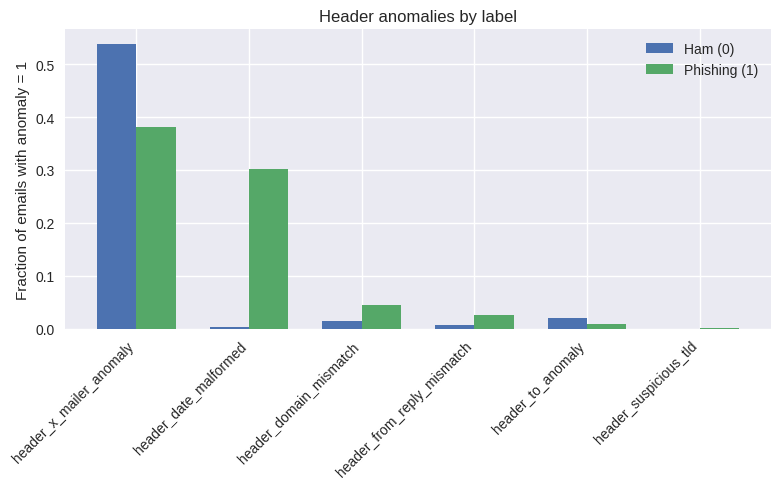

In [89]:
# 10. Compare binary header anomalies between ham (0) and phishing (1)

if binary_anoms:
    grouped_means = df.groupby("label")[binary_anoms].mean().T  # rows = features, cols = labels
    grouped_means = grouped_means.sort_values(by=1, ascending=False)  # sort by phishing prevalence

    plt.figure(figsize=(8,5))
    x = np.arange(len(grouped_means.index))
    width = 0.35

    plt.bar(x - width/2, grouped_means[0], width, label="Ham (0)")
    plt.bar(x + width/2, grouped_means[1], width, label="Phishing (1)")

    plt.xticks(x, grouped_means.index, rotation=45, ha="right")
    plt.ylabel("Fraction of emails with anomaly = 1")
    plt.title("Header anomalies by label")
    plt.legend()
    plt.tight_layout()
    plt.show()

    grouped_means
else:
    print("No binary anomalies to compare.")


# Distribution of `header_received_count`

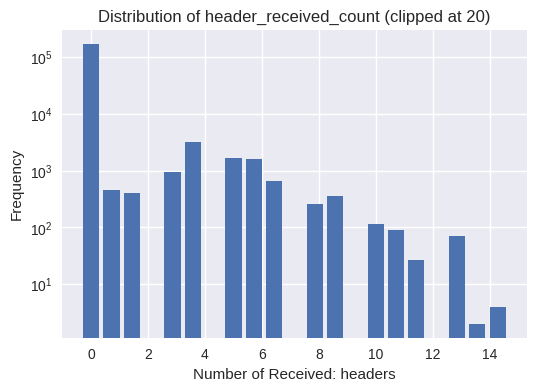

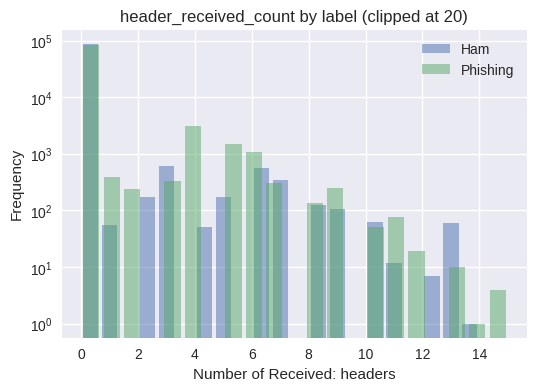

In [90]:
# 11. Distribution of header_received_count

if "header_received_count" in df.columns:
    # Clip to avoid very long tail in visualization
    clipped = df["header_received_count"].clip(lower=0, upper=20)

    plt.figure(figsize=(6,4))
    plt.hist(clipped, bins=21, align="left", rwidth=0.8)
    plt.title("Distribution of header_received_count (clipped at 20)")
    plt.xlabel("Number of Received: headers")
    plt.ylabel("Frequency")
    plt.yscale("log")
    plt.show()

    # Optional: compare by label
    plt.figure(figsize=(6,4))
    for label_value, label_name in [(0, "Ham"), (1, "Phishing")]:
        subset = df[df["label"] == label_value]["header_received_count"].clip(0, 20)
        plt.hist(subset, bins=21, alpha=0.5, label=label_name, rwidth=0.8)

    plt.title("header_received_count by label (clipped at 20)")
    plt.xlabel("Number of Received: headers")
    plt.ylabel("Frequency")
    plt.yscale("log")
    plt.legend()
    plt.show()
else:
    print("Column header_received_count not found.")


# Correlation between anomalies & label

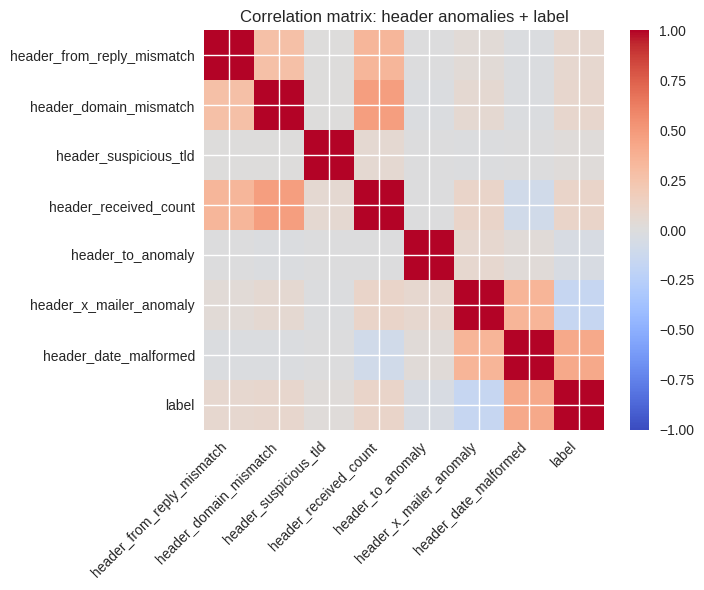

label                         1.000000
header_date_malformed         0.415920
header_received_count         0.102148
header_domain_mismatch        0.084856
header_from_reply_mismatch    0.073348
header_suspicious_tld         0.016717
header_to_anomaly            -0.046715
header_x_mailer_anomaly      -0.157274
Name: label, dtype: float64

In [91]:
# 12. Correlation matrix for anomaly features + label

cols_for_corr = header_cols + ["label"]
corr_df = df[cols_for_corr].corr()

plt.figure(figsize=(8,6))
im = plt.imshow(corr_df, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(len(cols_for_corr)), cols_for_corr, rotation=45, ha="right")
plt.yticks(range(len(cols_for_corr)), cols_for_corr)
plt.title("Correlation matrix: header anomalies + label")
plt.tight_layout()
plt.show()

corr_df["label"].sort_values(ascending=False)